In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from scipy import stats

import torch

In [2]:
def sigmoid(x):
  return 1 / (1 + np.exp(-x))

def get_dist_weight(dist, smooth, force):
    return sigmoid(smooth / (1 + dist) - force * smooth) / sigmoid(smooth - force * smooth)

def get_weighted_dist(dist, smooth, force):
    return 1 / (1 + dist) * get_dist_weight(dist, smooth, force)

MODEL original
R_SQUARED: 0.02791 ± 0.00305


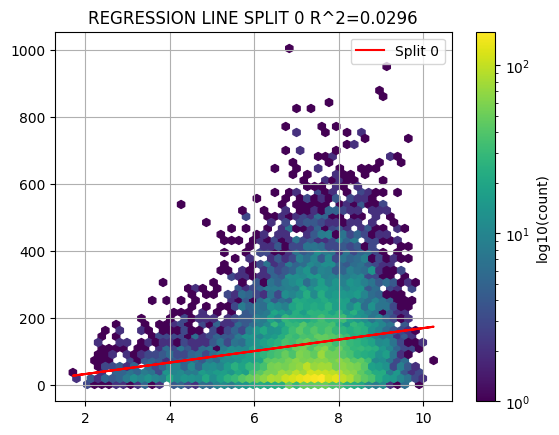

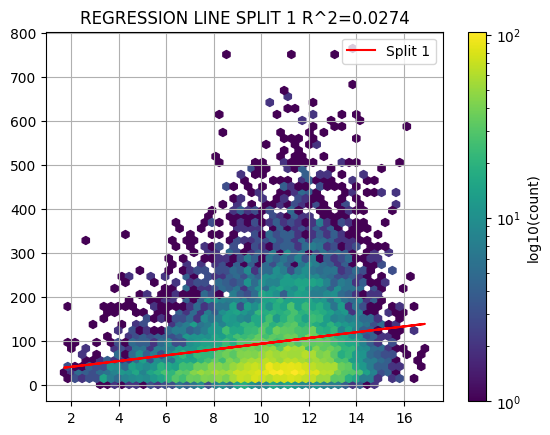

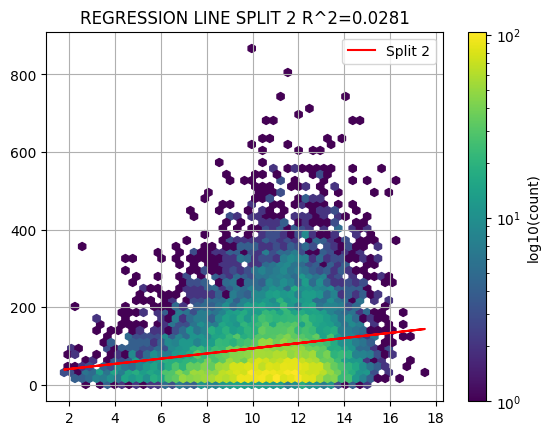

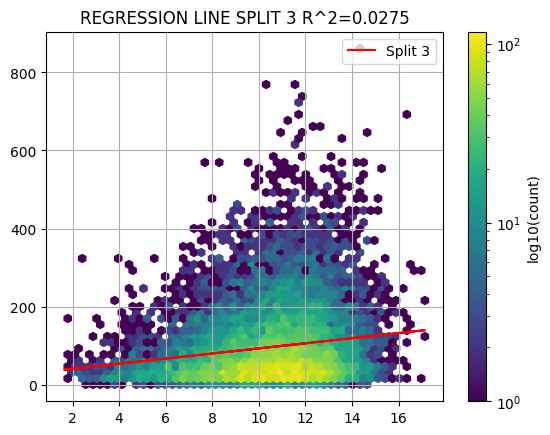

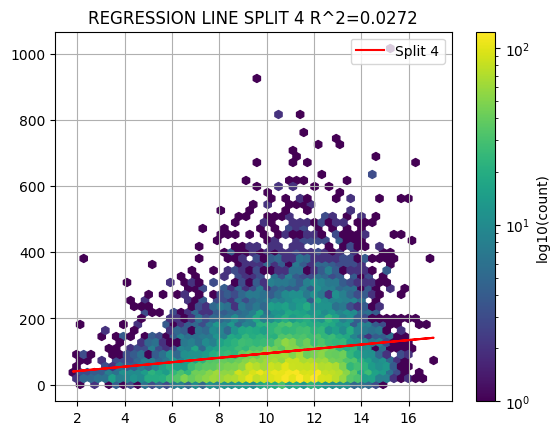

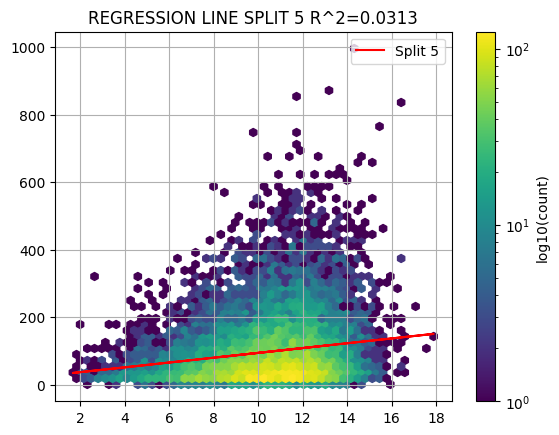

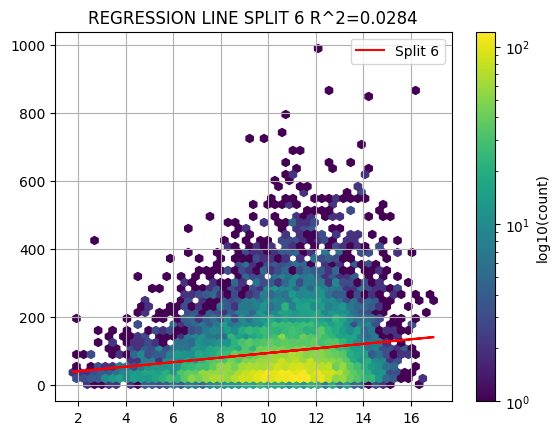

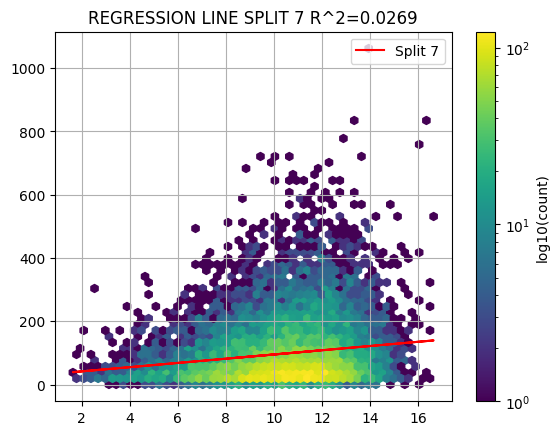

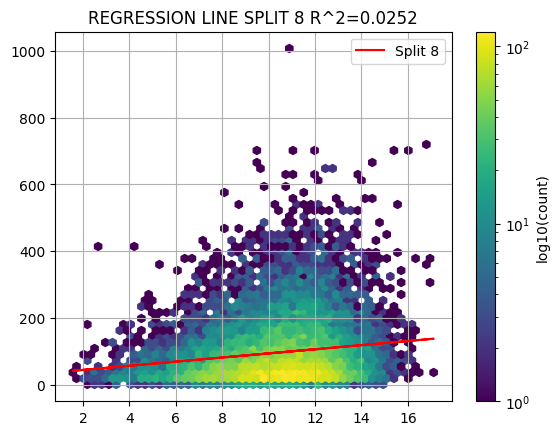

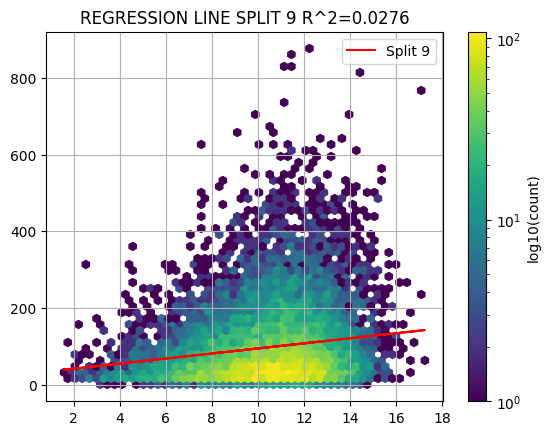

In [3]:
model_name = 'original'

df = pd.read_csv(f'../analysis/sim_analysis/dtw_{model_name}.csv')


rsquared_list = []

space = np.linspace(df['item_dist'].min(), df['item_dist'].max(), 100)

for s in df['split'].unique():    
    df_tmp = df[df['split']==s]

    dist = df_tmp['item_dist'].to_numpy()
    prob = df_tmp['score'].to_numpy()
    
    
    dist_sm = sm.add_constant(dist)  
    model = sm.OLS(prob, dist_sm)    
    results = model.fit()     
    rsquared_list.append(results.rsquared)
    plt.figure()
    plt.plot(dist, results.predict(dist_sm), label=f'Split {s}', color='red')
    plt.legend()
    plt.grid()
    plt.title(f'REGRESSION LINE SPLIT {s} R^2={results.rsquared:.4f}')
    # plt.legend()
    plt.hexbin(x=df_tmp['item_dist'], y=df_tmp['score'],gridsize=50, cmap="viridis", bins='log')
    plt.colorbar(label='log10(count)')



print(f'MODEL {model_name}')
print(f'R_SQUARED: {np.mean(rsquared_list):.5f} ± {1.96*np.std(rsquared_list):.5f}')

/tmp/ipykernel_1407/3301597717.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_tmp['item_dist'] = get_weighted_dist(df_tmp['item_dist'], smooth, force)


MODEL extended
R_SQUARED: 0.02150 ± 0.00368


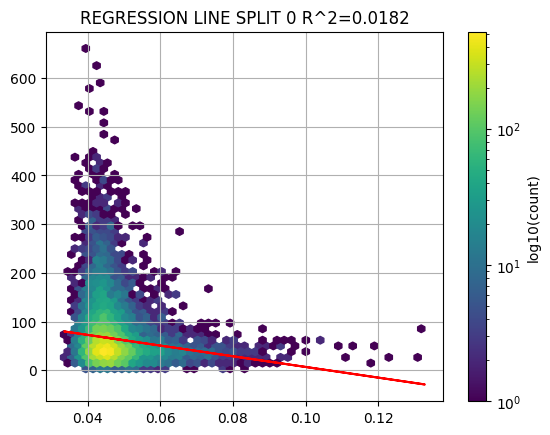

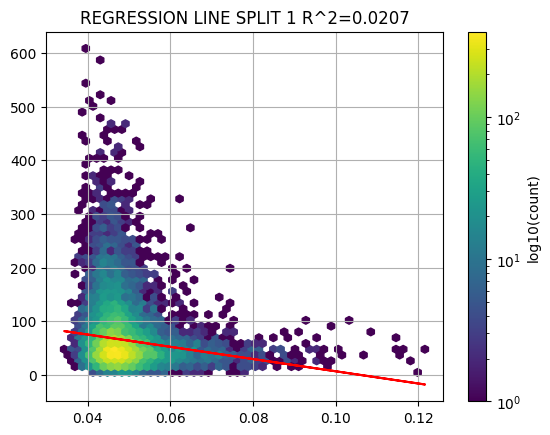

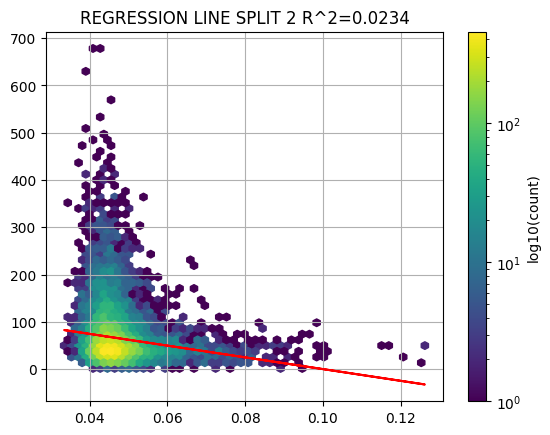

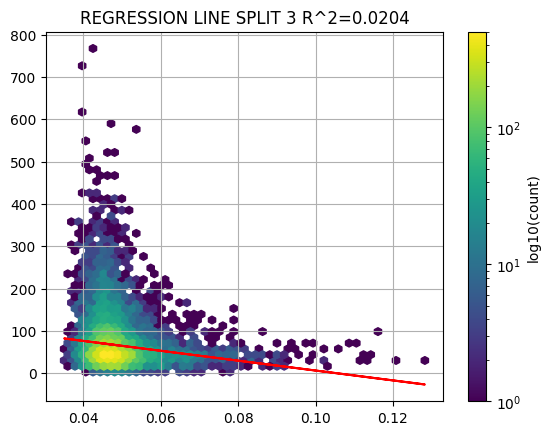

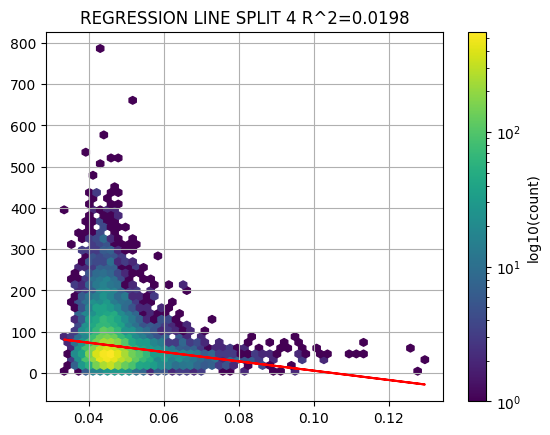

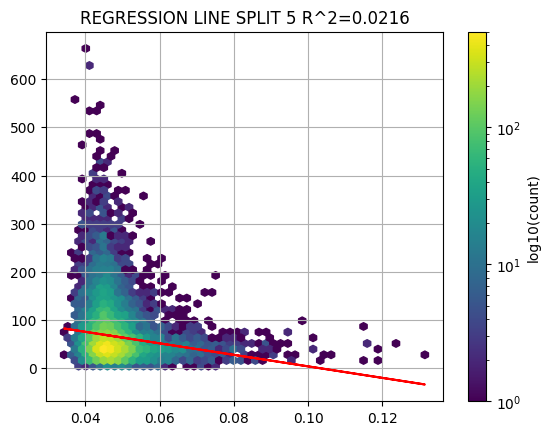

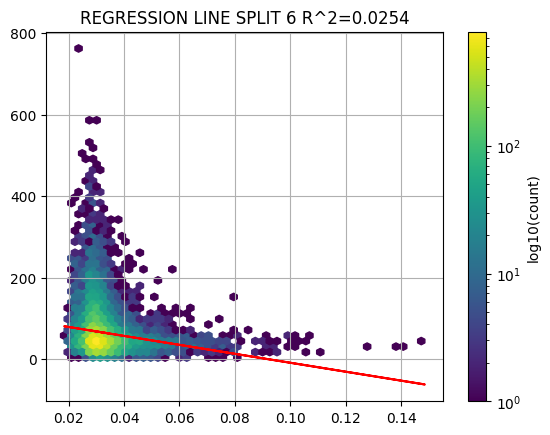

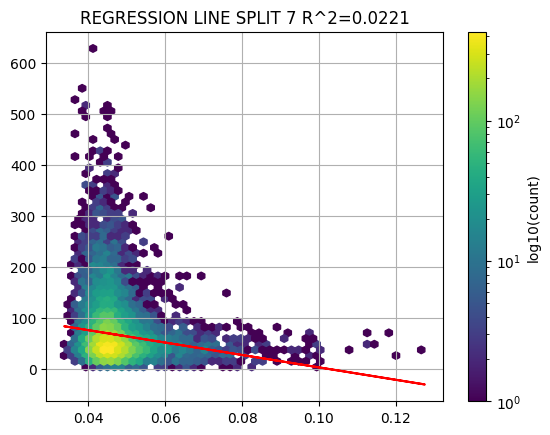

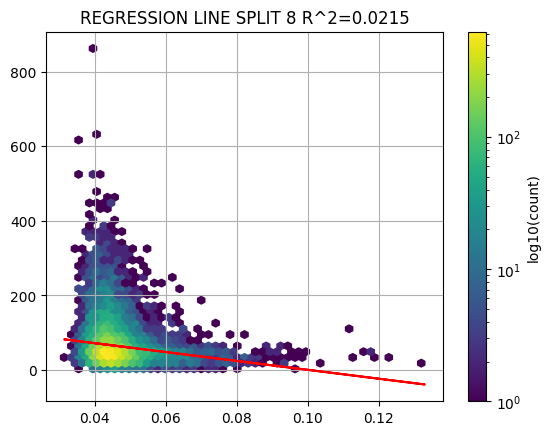

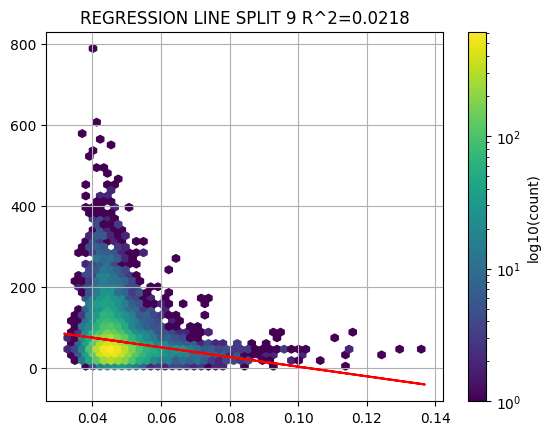

In [4]:
model_name = 'extended'

df = pd.read_csv(f'../analysis/sim_analysis/dtw_{model_name}.csv')


rsquared_list = []

space = np.linspace(df['item_dist'].min(), df['item_dist'].max(), 100)

for s in df['split'].unique():

    weights = torch.load(f'../checkpoints/{model_name}/split_{s}/checkpoint_best.pt', map_location='cpu')
    smooth = float(weights['model_state_dict']['smooth'].numpy())
    force = float(weights['model_state_dict']['force'].numpy())

    
    df_tmp = df[df['split']==s]

    df_tmp['item_dist'] = get_weighted_dist(df_tmp['item_dist'], smooth, force)

    dist = df_tmp['item_dist'].to_numpy()
    prob = df_tmp['score'].to_numpy()
    
    
    dist_sm = sm.add_constant(dist)  
    model = sm.OLS(prob, dist_sm)    
    results = model.fit()     
    rsquared_list.append(results.rsquared)
    plt.figure()
    plt.plot(dist, results.predict(dist_sm), label=f'Split {s}', color='red')
    # plt.legend()
    plt.grid()
    plt.title(f'REGRESSION LINE SPLIT {s} R^2={results.rsquared:.4f}')
    # plt.legend()
    plt.hexbin(x=df_tmp['item_dist'], y=df_tmp['score'],gridsize=50, cmap="viridis", bins='log')
    plt.colorbar(label='log10(count)')
    # plt.ylim(-0.1, 1.1)


print(f'MODEL {model_name}')
print(f'R_SQUARED: {np.mean(rsquared_list):.5f} ± {1.96*np.std(rsquared_list):.5f}')

/tmp/ipykernel_1407/665286567.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_tmp['item_dist_base'] = get_weighted_dist(df_tmp['item_dist_base'], smooth, force)
/tmp/ipykernel_1407/665286567.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_tmp['item_dist_ext'] = get_weighted_dist(df_tmp['item_dist_ext'], smooth, force)


MODEL extendedDoubleBase
R_SQUARED BASE: 0.01986 ± 0.00242
R_SQUARED EXT: 0.00041 ± 0.00032


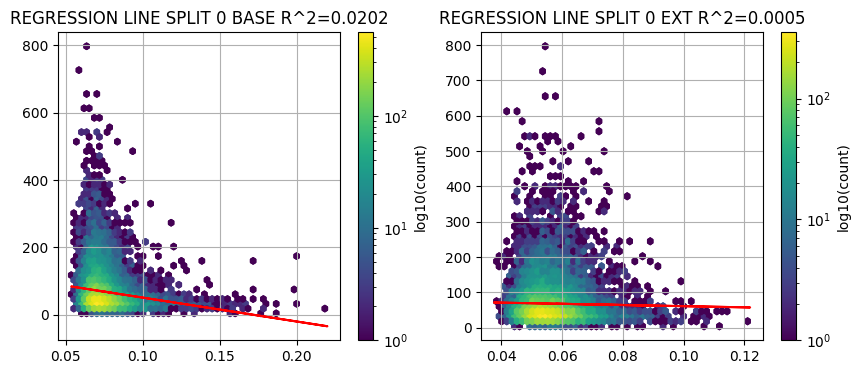

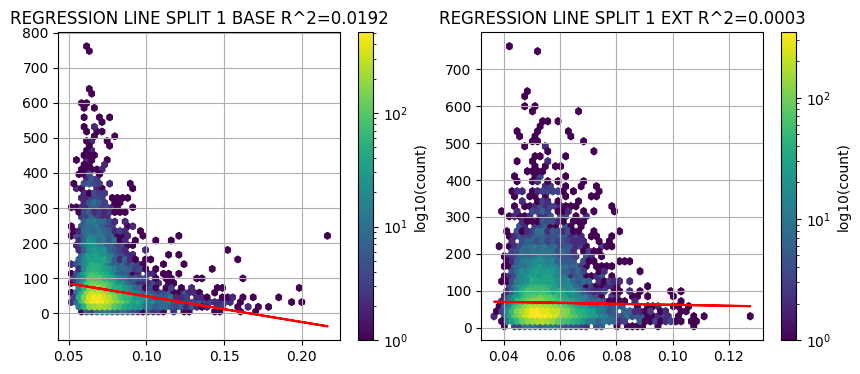

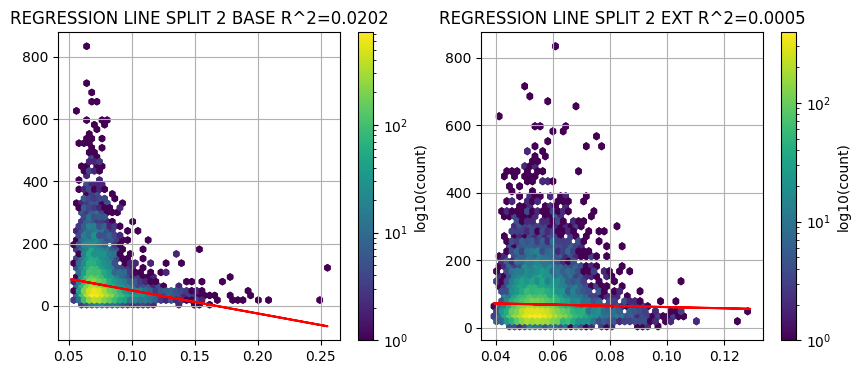

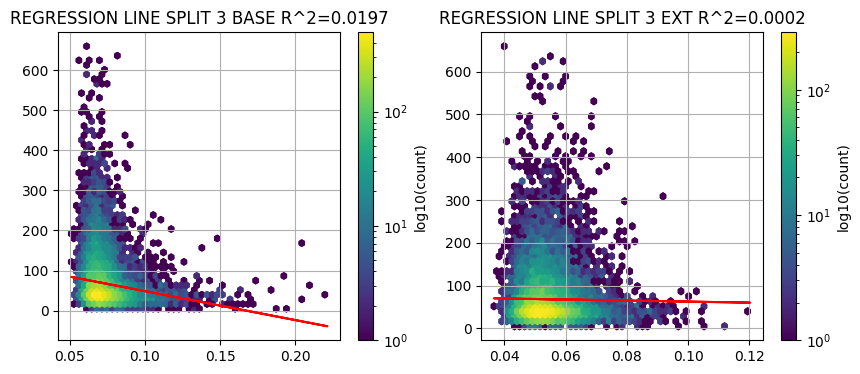

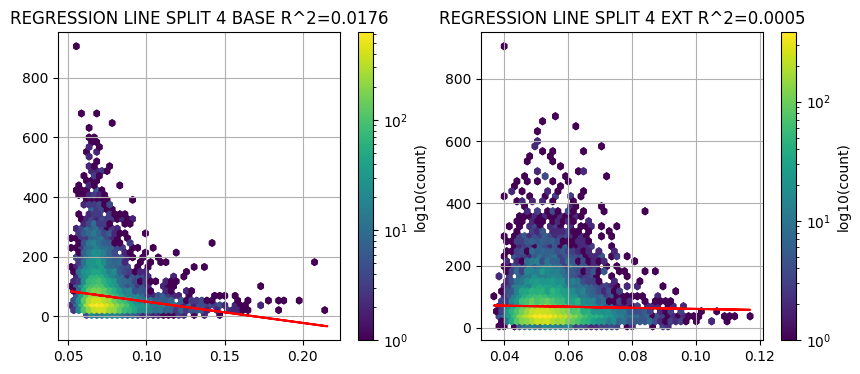

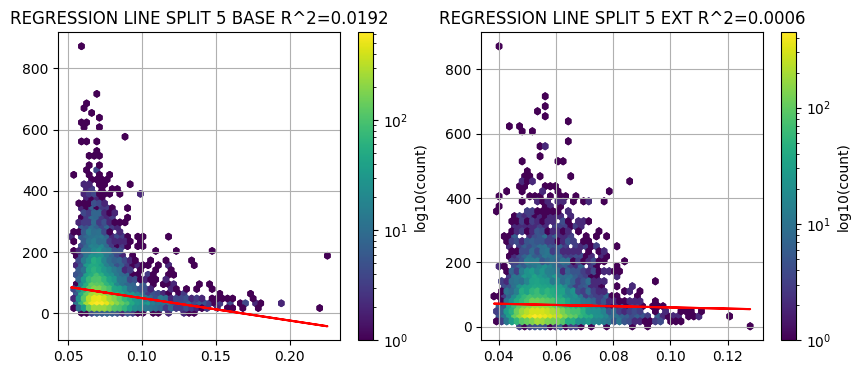

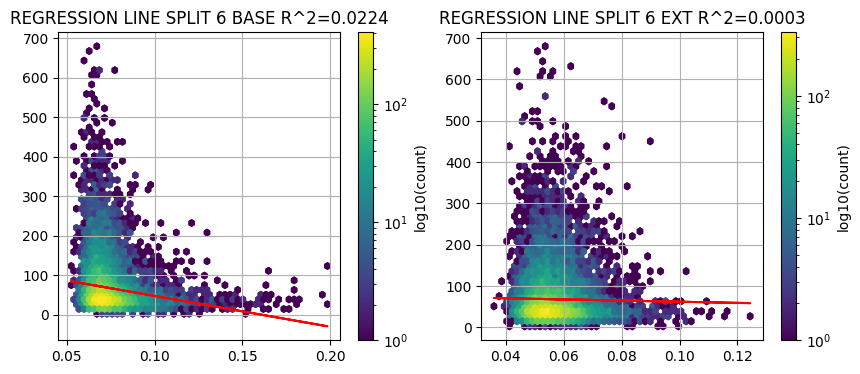

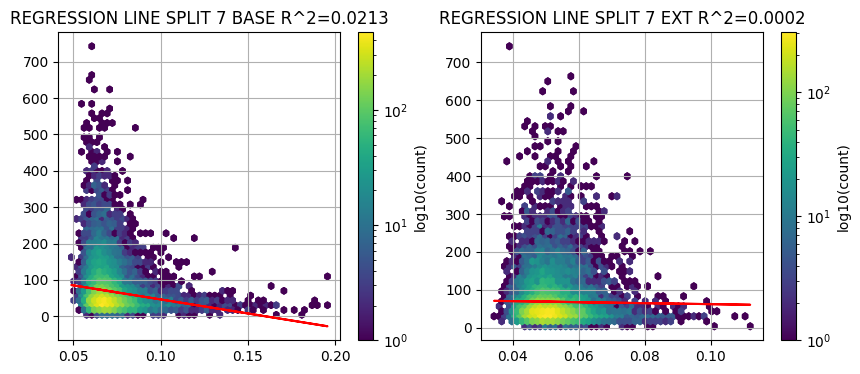

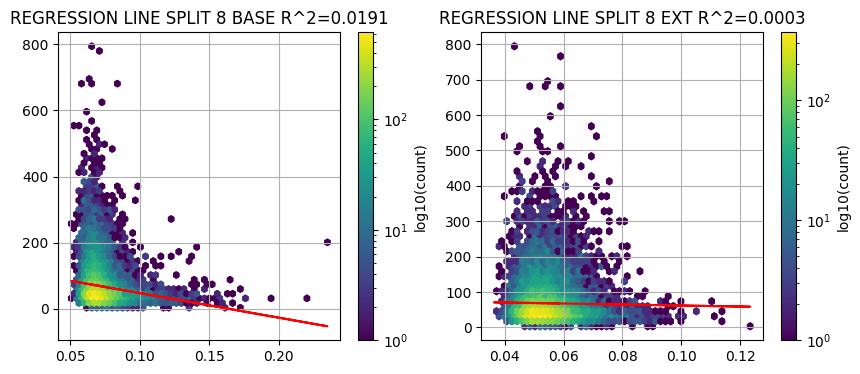

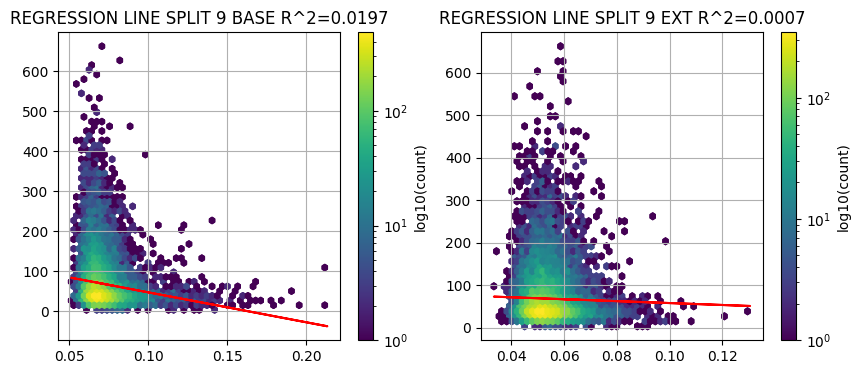

In [5]:
model_name = 'extendedDoubleBase'

df = pd.read_csv(f'../analysis/sim_analysis/dtw_{model_name}.csv')


b_rsquared_list = []
e_rsquared_list = []

for s in df['split'].unique():
    weights = torch.load(f'../checkpoints/{model_name}/split_{s}/checkpoint_best.pt', map_location='cpu')
    smooth = float(weights['model_state_dict']['smooth'].numpy())
    force = float(weights['model_state_dict']['force'].numpy())

    
    df_tmp = df[df['split']==s]

    df_tmp['item_dist_base'] = get_weighted_dist(df_tmp['item_dist_base'], smooth, force)
    df_tmp['item_dist_ext'] = get_weighted_dist(df_tmp['item_dist_ext'], smooth, force)

    b_dist = df_tmp['item_dist_base'].to_numpy()
    e_dist = df_tmp['item_dist_ext'].to_numpy()
    prob = df_tmp['score'].to_numpy()

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    
    
    b_dist_sm = sm.add_constant(b_dist)  
    b_model = sm.OLS(prob, b_dist_sm)    
    b_results = b_model.fit()     
    b_rsquared_list.append(b_results.rsquared)

    

    
    axes[0].plot(b_dist, b_results.predict(b_dist_sm), label=f'Split {s} base emb', color='red')
    axes[0].grid()
    axes[0].set_title(f'REGRESSION LINE SPLIT {s} BASE R^2={b_results.rsquared:.4f}')
    axes[0].hexbin(x=df_tmp['item_dist_base'], y=df_tmp['score'],gridsize=50, cmap="viridis", bins='log')

    hb = axes[0].hexbin(
                x=df_tmp['item_dist_base'],
                y=df_tmp['score'],
                gridsize=50,
                cmap="viridis",
                bins='log'
            )

    fig.colorbar(hb, ax=axes[0], label='log10(count)')

    
    e_dist_sm = sm.add_constant(e_dist)  
    e_model = sm.OLS(prob, e_dist_sm)    
    e_results = e_model.fit()     
    e_rsquared_list.append(e_results.rsquared)

    

    
    axes[1].plot(e_dist, e_results.predict(e_dist_sm), label=f'Split {s} base ext', color='red')
    axes[1].grid()
    axes[1].set_title(f'REGRESSION LINE SPLIT {s} EXT R^2={e_results.rsquared:.4f}')
    axes[1].hexbin(x=df_tmp['item_dist_ext'], y=df_tmp['score'],gridsize=50, cmap="viridis", bins='log')

    hb = axes[1].hexbin(
                x=df_tmp['item_dist_ext'],
                y=df_tmp['score'],
                gridsize=50,
                cmap="viridis",
                bins='log'
            )

    fig.colorbar(hb, ax=axes[1], label='log10(count)')

    # axes[0].set_ylim(-1.1, 1.1)
    # axes[1].set_ylim(-1.1, 1.1)



print(f'MODEL {model_name}')
print(f'R_SQUARED BASE: {np.mean(b_rsquared_list):.5f} ± {1.96*np.std(b_rsquared_list):.5f}')
print(f'R_SQUARED EXT: {np.mean(e_rsquared_list):.5f} ± {1.96*np.std(e_rsquared_list):.5f}')

/tmp/ipykernel_1407/3239006506.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_tmp['item_dist_base'] = get_weighted_dist(df_tmp['item_dist_base'], smooth, force)
/tmp/ipykernel_1407/3239006506.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_tmp['item_dist_ext'] = get_weighted_dist(df_tmp['item_dist_ext'], smooth, force)


MODEL extendedDoubleEmb
R_SQUARED BASE: 0.01660 ± 0.00322
R_SQUARED EXT: 0.01075 ± 0.00380


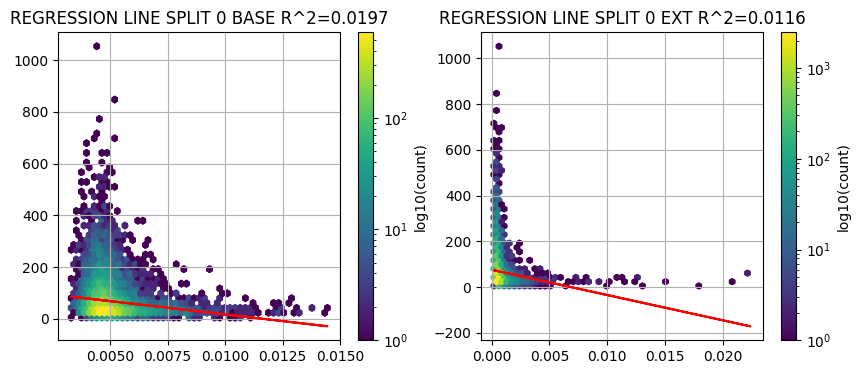

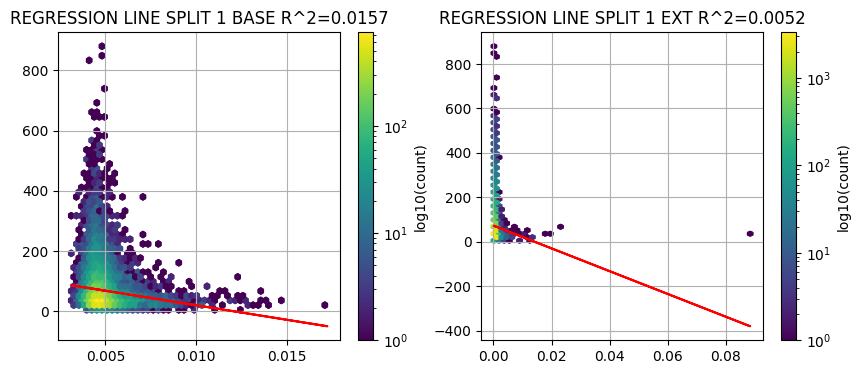

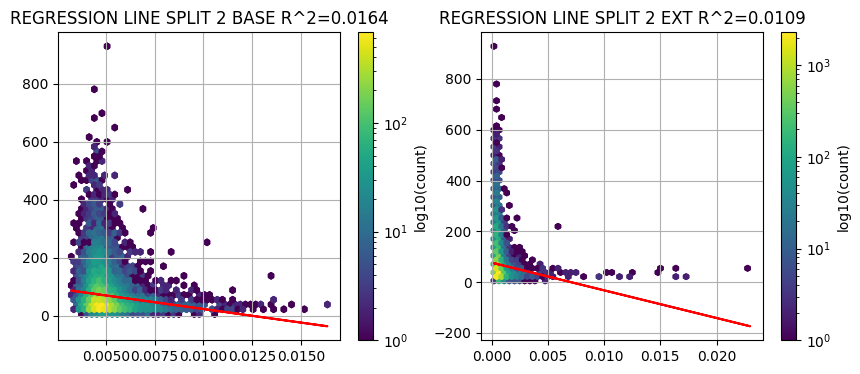

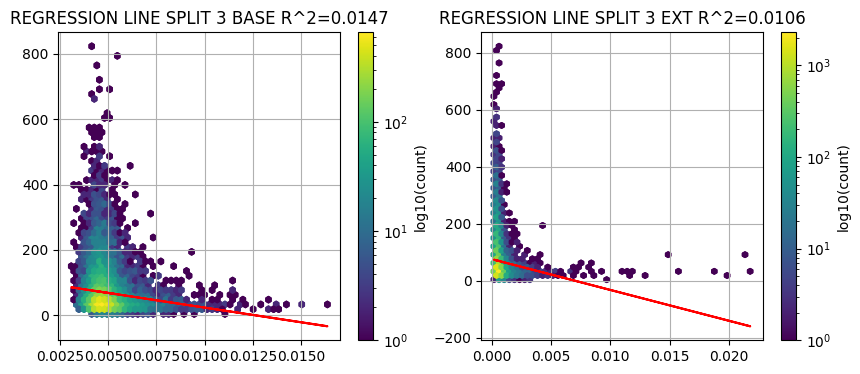

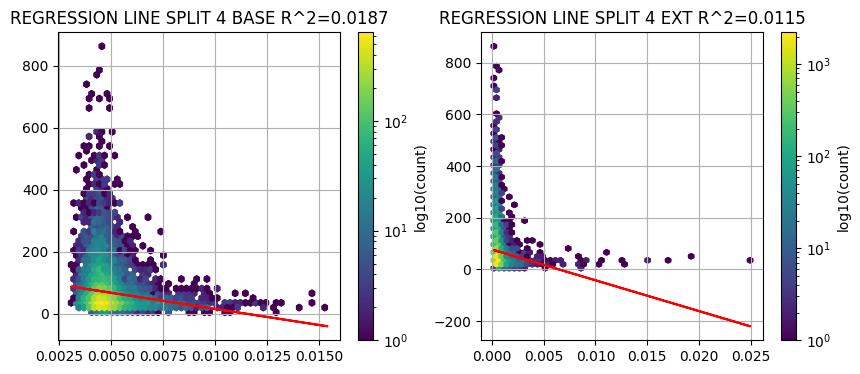

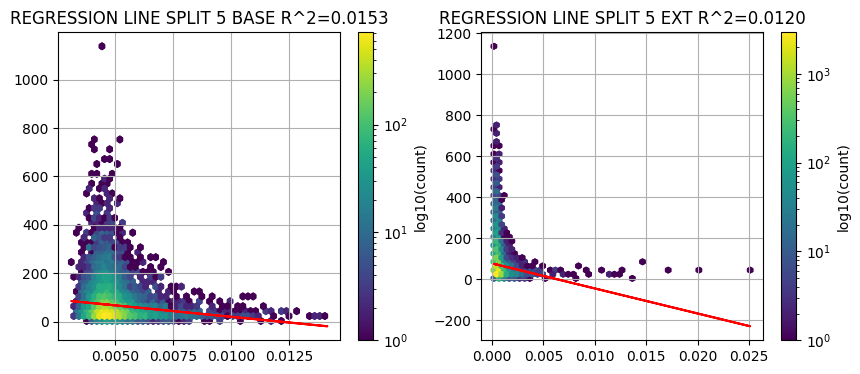

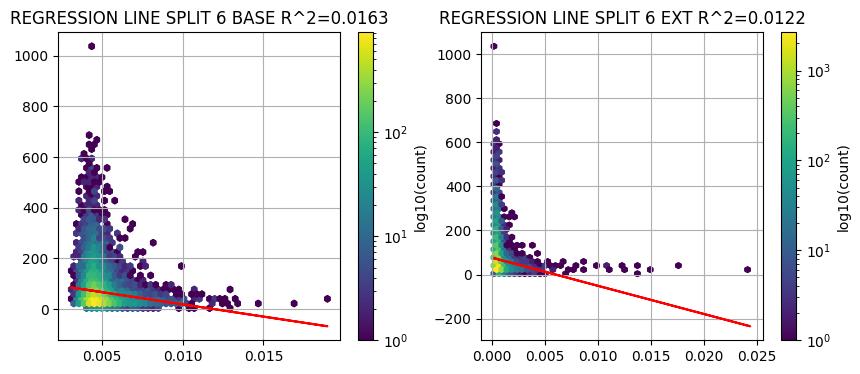

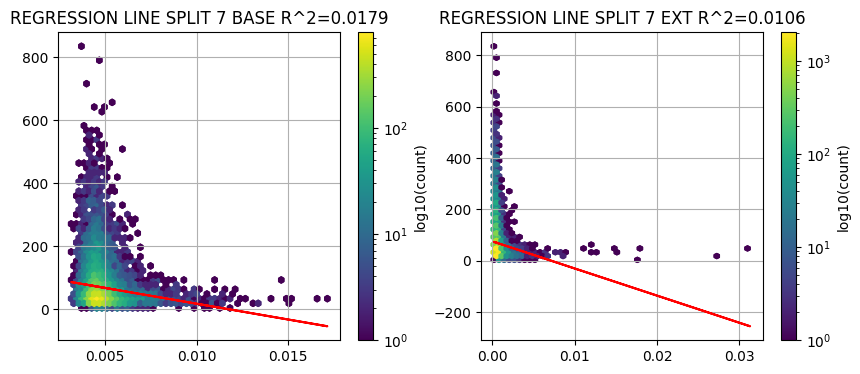

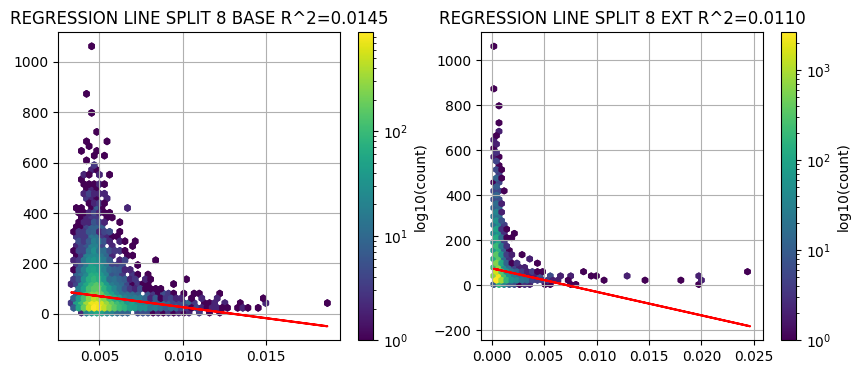

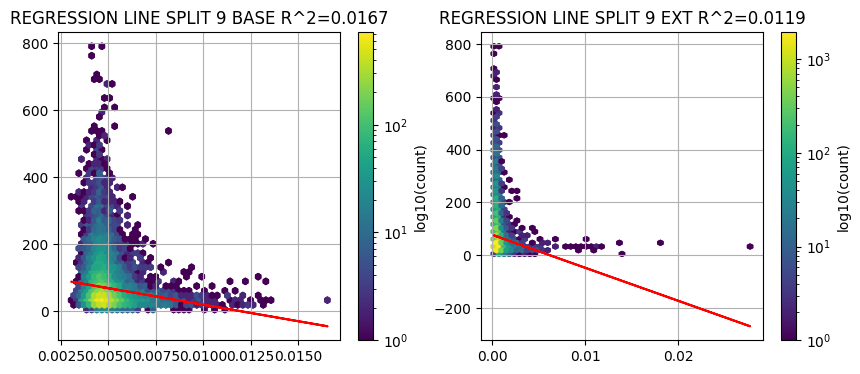

In [6]:
model_name = 'extendedDoubleEmb'

df = pd.read_csv(f'../analysis/sim_analysis/dtw_{model_name}.csv')


b_rsquared_list = []
e_rsquared_list = []

for s in df['split'].unique():
    weights = torch.load(f'../checkpoints/{model_name}/split_{s}/checkpoint_best.pt', map_location='cpu')
    smooth = float(weights['model_state_dict']['smooth'].numpy())
    force = float(weights['model_state_dict']['force'].numpy())

    
    df_tmp = df[df['split']==s]

    df_tmp['item_dist_base'] = get_weighted_dist(df_tmp['item_dist_base'], smooth, force)
    df_tmp['item_dist_ext'] = get_weighted_dist(df_tmp['item_dist_ext'], smooth, force)

    b_dist = df_tmp['item_dist_base'].to_numpy()
    e_dist = df_tmp['item_dist_ext'].to_numpy()
    prob = df_tmp['score'].to_numpy()

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    
    
    b_dist_sm = sm.add_constant(b_dist)  
    b_model = sm.OLS(prob, b_dist_sm)    
    b_results = b_model.fit()     
    b_rsquared_list.append(b_results.rsquared)

    

    
    axes[0].plot(b_dist, b_results.predict(b_dist_sm), label=f'Split {s} base emb', color='red')
    axes[0].grid()
    axes[0].set_title(f'REGRESSION LINE SPLIT {s} BASE R^2={b_results.rsquared:.4f}')
    axes[0].hexbin(x=df_tmp['item_dist_base'], y=df_tmp['score'],gridsize=50, cmap="viridis", bins='log')

    hb = axes[0].hexbin(
                x=df_tmp['item_dist_base'],
                y=df_tmp['score'],
                gridsize=50,
                cmap="viridis",
                bins='log'
            )

    fig.colorbar(hb, ax=axes[0], label='log10(count)')

    
    e_dist_sm = sm.add_constant(e_dist)  
    e_model = sm.OLS(prob, e_dist_sm)    
    e_results = e_model.fit()     
    e_rsquared_list.append(e_results.rsquared)

    

    
    axes[1].plot(e_dist, e_results.predict(e_dist_sm), label=f'Split {s} base ext', color='red')
    axes[1].grid()
    axes[1].set_title(f'REGRESSION LINE SPLIT {s} EXT R^2={e_results.rsquared:.4f}')
    axes[1].hexbin(x=df_tmp['item_dist_ext'], y=df_tmp['score'],gridsize=50, cmap="viridis", bins='log')

    hb = axes[1].hexbin(
                x=df_tmp['item_dist_ext'],
                y=df_tmp['score'],
                gridsize=50,
                cmap="viridis",
                bins='log'
            )

    fig.colorbar(hb, ax=axes[1], label='log10(count)')
    # axes[0].set_ylim(-1.1, 1.1)
    # axes[1].set_ylim(-1.1, 1.1)



print(f'MODEL {model_name}')
print(f'R_SQUARED BASE: {np.mean(b_rsquared_list):.5f} ± {1.96*np.std(b_rsquared_list):.5f}')
print(f'R_SQUARED EXT: {np.mean(e_rsquared_list):.5f} ± {1.96*np.std(e_rsquared_list):.5f}')

/tmp/ipykernel_1407/568667897.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_tmp['item_dist_base'] = get_weighted_dist(df_tmp['item_dist_base'], smooth, force)
/tmp/ipykernel_1407/568667897.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_tmp['item_dist_ext'] = get_weighted_dist(df_tmp['item_dist_ext'], smooth, force)


MODEL extendedDoubleEmbFreeze
R_SQUARED BASE: 0.01437 ± 0.00174
R_SQUARED EXT: 0.01632 ± 0.00137


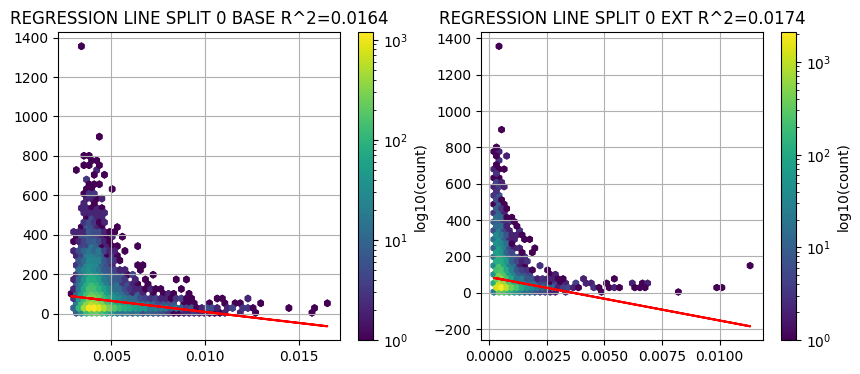

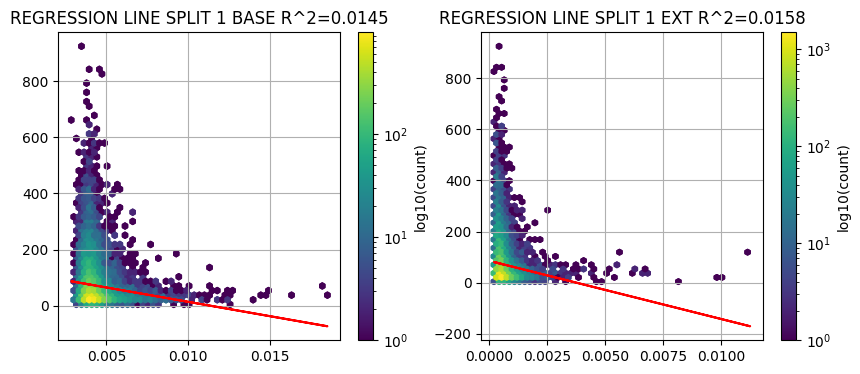

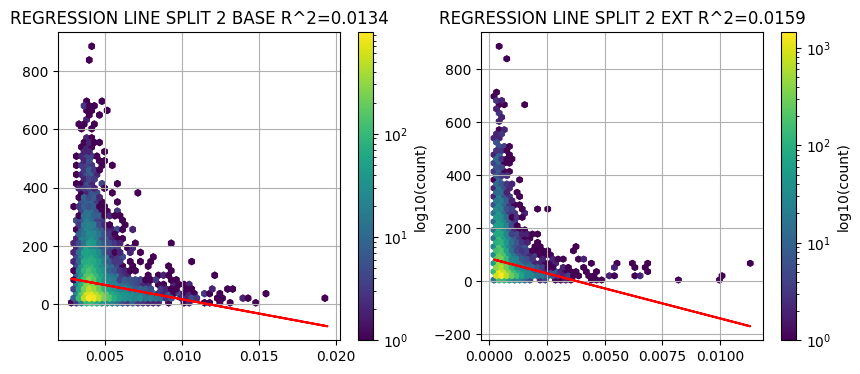

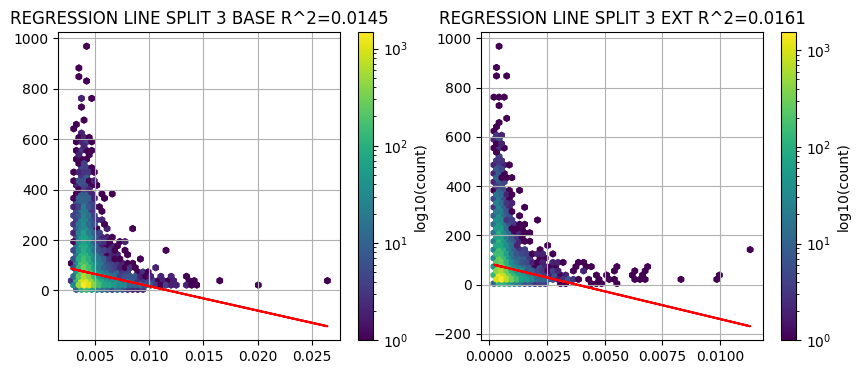

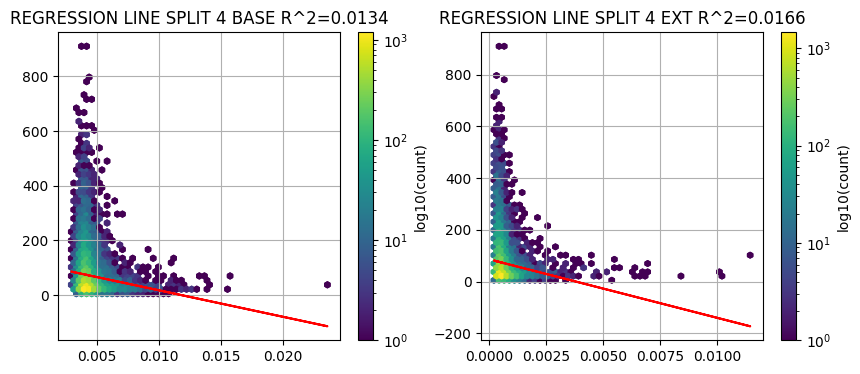

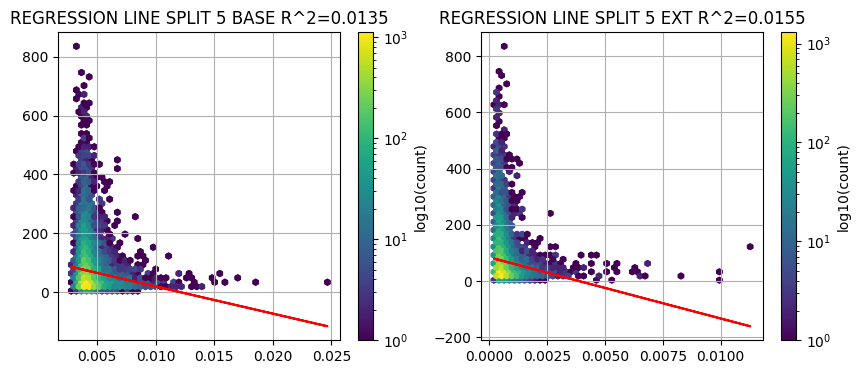

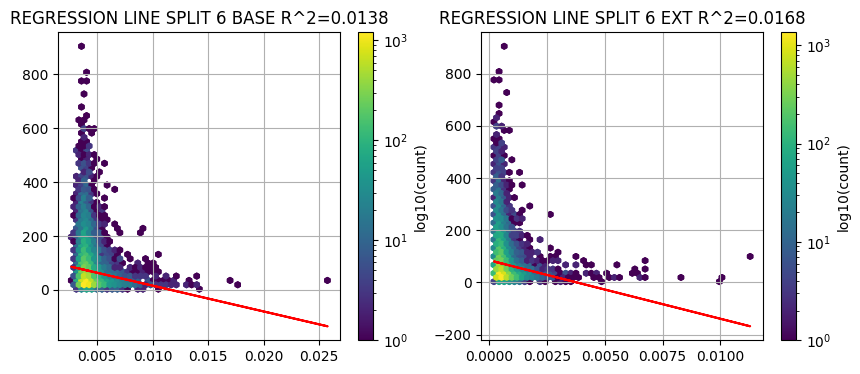

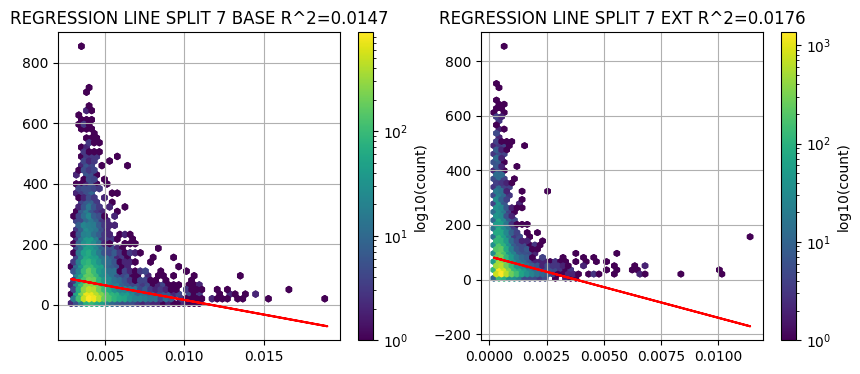

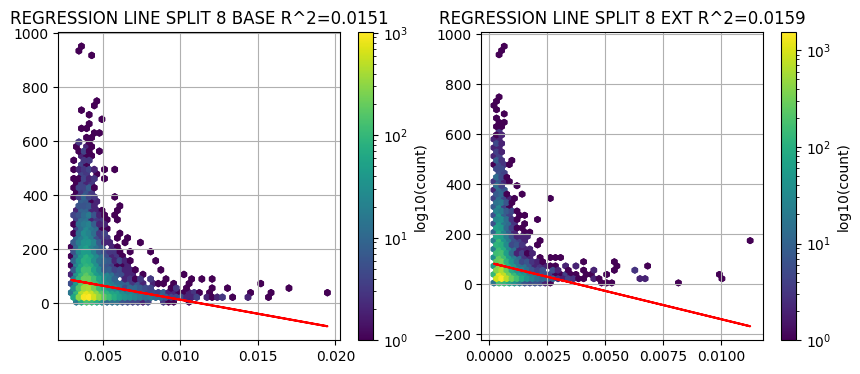

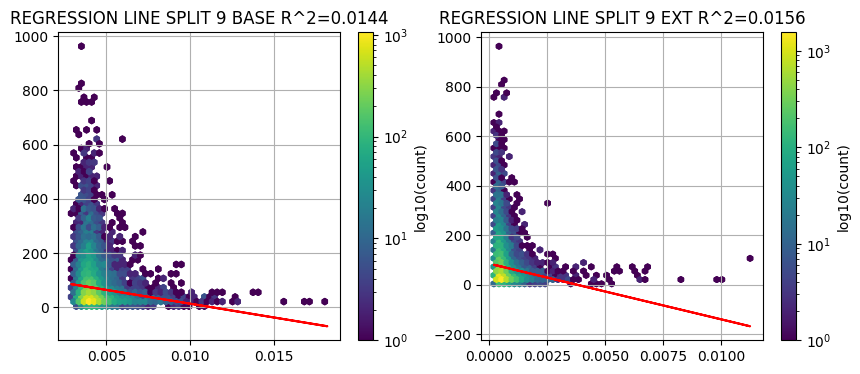

In [7]:
model_name = 'extendedDoubleEmbFreeze'

df = pd.read_csv(f'../analysis/sim_analysis/dtw_{model_name}.csv')


b_rsquared_list = []
e_rsquared_list = []

for s in df['split'].unique():
    weights = torch.load(f'../checkpoints/{model_name}/split_{s}/checkpoint_best.pt', map_location='cpu')
    smooth = float(weights['model_state_dict']['smooth'].numpy())
    force = float(weights['model_state_dict']['force'].numpy())

    
    df_tmp = df[df['split']==s]

    df_tmp['item_dist_base'] = get_weighted_dist(df_tmp['item_dist_base'], smooth, force)
    df_tmp['item_dist_ext'] = get_weighted_dist(df_tmp['item_dist_ext'], smooth, force)

    b_dist = df_tmp['item_dist_base'].to_numpy()
    e_dist = df_tmp['item_dist_ext'].to_numpy()
    prob = df_tmp['score'].to_numpy()

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    
    
    b_dist_sm = sm.add_constant(b_dist)  
    b_model = sm.OLS(prob, b_dist_sm)    
    b_results = b_model.fit()     
    b_rsquared_list.append(b_results.rsquared)

    

    
    axes[0].plot(b_dist, b_results.predict(b_dist_sm), label=f'Split {s} base emb', color='red')
    axes[0].grid()
    axes[0].set_title(f'REGRESSION LINE SPLIT {s} BASE R^2={b_results.rsquared:.4f}')
    axes[0].hexbin(x=df_tmp['item_dist_base'], y=df_tmp['score'],gridsize=50, cmap="viridis", bins='log')

    hb = axes[0].hexbin(
                x=df_tmp['item_dist_base'],
                y=df_tmp['score'],
                gridsize=50,
                cmap="viridis",
                bins='log'
            )

    fig.colorbar(hb, ax=axes[0], label='log10(count)')

    
    e_dist_sm = sm.add_constant(e_dist)  
    e_model = sm.OLS(prob, e_dist_sm)    
    e_results = e_model.fit()     
    e_rsquared_list.append(e_results.rsquared)

    

    
    axes[1].plot(e_dist, e_results.predict(e_dist_sm), label=f'Split {s} base ext', color='red')
    axes[1].grid()
    axes[1].set_title(f'REGRESSION LINE SPLIT {s} EXT R^2={e_results.rsquared:.4f}')
    axes[1].hexbin(x=df_tmp['item_dist_ext'], y=df_tmp['score'],gridsize=50, cmap="viridis", bins='log')

    hb = axes[1].hexbin(
                x=df_tmp['item_dist_ext'],
                y=df_tmp['score'],
                gridsize=50,
                cmap="viridis",
                bins='log'
            )

    fig.colorbar(hb, ax=axes[1], label='log10(count)')
    # axes[0].set_ylim(-1.1, 1.1)
    # axes[1].set_ylim(-1.1, 1.1)



print(f'MODEL {model_name}')
print(f'R_SQUARED BASE: {np.mean(b_rsquared_list):.5f} ± {1.96*np.std(b_rsquared_list):.5f}')
print(f'R_SQUARED EXT: {np.mean(e_rsquared_list):.5f} ± {1.96*np.std(e_rsquared_list):.5f}')